# Exploratory Data Analysis

In the following sections, I will perform two unique types of exploratory data analysis, namely:
1. Basic statistical profiling.
2. Lexical analysis 
These will be conducted from the entire dataset, as provided in [dontpatronizeme_pcl.tsv](https://github.com/CRLala/NLPLabs-2024/blob/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv). 

In [53]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [54]:
import pandas as pd 
import numpy as np 
import spacy
import matplotlib
import transformers
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import nltk

In [55]:
MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=False)

In [56]:
DATA_PATH = "data"
DATASET_PATH = f"{DATA_PATH}/dontpatronizeme_pcl.tsv"

raw_data = pd.read_csv(DATASET_PATH, sep="\t", header=None)
raw_data.columns = ["id", "doc_id", "keyword", "country_code", "text", "label"]
raw_data.head()

,id,doc_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


## Basic Statistical Profiling

### 1. Class Distribution
Here, we will analyse the instances of each class label. Notably, we have integer class labels [0,4] within the dataset. Particularly, each paragraph has been annotated by two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The class labels indicate the sum of the scores of both annotators. 

,count,relative_frequency
label,,
0,8529,81.47
1,947,9.05
2,144,1.38
3,458,4.37
4,391,3.73


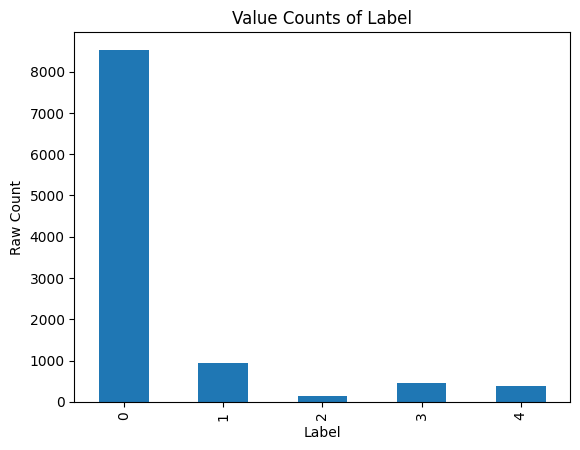

In [57]:
# Raw label counts & relative frequencies
def class_distr(dataset: pd.DataFrame):
    counts = dataset["label"].value_counts(sort=False)
    relative_freq = (dataset["label"].value_counts(sort=False, normalize=True) * 100).round(2)

    summary_df = pd.DataFrame({
        "count": counts,
        "relative_frequency": relative_freq
    })

    display(summary_df)

    # Bar plot (raw counts)
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel("Label")
    plt.ylabel("Raw Count")
    plt.title("Value Counts of Label")
    plt.show()

    return summary_df

distr = class_distr(raw_data)

**Analysis**: The label distribution reveals severe class imbalance, with 81.47% of samples labelled as having no/very weak PCL (labels 0/1) and only ~8% labelled as clear PCL (labels 3–4). This indicates that the dataset is heavily skewed toward non-PCL examples, which may bias a model toward predicting the majority class. Moreover, it could mean there is not sufficient data within the positive class for the model to learn meaningful patterns of patronising language.

In addition to this, Label 2 reflects annotator uncertainty, capturing instances where the language is sufficiently subtle to be interpreted as either PCL or non-PCL. As these examples do not form a clearly defined class, forcing them into either category risks introducing label noise and weakening the model’s ability to learn a consistent decision boundary about what constitutes PCL. Furthermore, label 2 constitutes only 1.38% of the dataset. Given this low frequency, removing these samples is unlikely to materially affect dataset size or representativeness, and may instead improve overall data quality by retaining only higher-confidence annotations.


**Impact**: To reduce annotation noise and create a clearer learning signal, label 2 samples will be removed. The remaining labels will be collapsed into a binary formulation: {0,1} → 0 (no PCL) and {3,4} → 1 (PCL).

,count,relative_frequency
label,,
0,9476,91.78
1,849,8.22


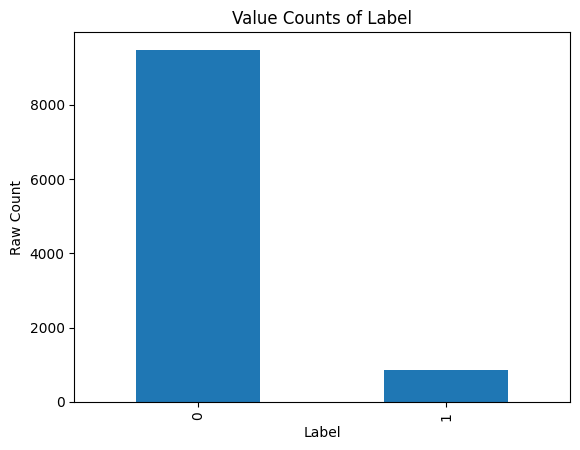

In [58]:
# Dropping label 2 from the dataset 

filtered_data = raw_data[raw_data["label"] != 2]

# Convert labels into a binary set.
label_map = {
    0: 0,  # no PCL
    1: 0,
    3: 1,  # PCL
    4: 1
}

filtered_data["label"] = filtered_data["label"].map(label_map)

# Recompute distribution statistics of binary task
distr = class_distr(filtered_data)



In [59]:
neg, pos = distr["count"][0], distr["count"][1]
print(f"No PCL : PCL ratio ≈ {neg/pos:.2f} : 1")

No PCL : PCL ratio ≈ 11.16 : 1


**Analysis & Impact**: As evident from the data and visualisations, i.e., an 11.16 : 1 Non PCL : PCL ratio, this label separation results in a strongly imbalanced binary dataset. Therefore, F1 score will be used as the primary evaluation metric, as it is more resistant to imbalanced data and reflects performance on the minority class better than accuracy. 

Moreover, additional mitigation strategies such as class weighting or targeted data augmentation of the possitive class may be necessary to ensure the model has sufficient training samples to effectively learn patterns associated with PCL.

### 2. Token Distribution
 -- What is the average, minimum, and maximum sentence length (in terms of tokens)?
As I plan to use the `RoBERTa-v3-base` encoder model for this task, I will be utilising the `RoBERTa-v3-base` tokeniser to compute all statistics regarding token counts and distributions. 

In [60]:
def tokenise_inputs(texts, add_special_tokens=True):
    return tokenizer(
        ["" if t is None else str(t) for t in texts],
        padding=False,
        truncation=False,
        add_special_tokens=add_special_tokens,
    )

def summarise(arr: np.ndarray, name: str) -> pd.DataFrame:
    """Common stats for 1D numeric array."""
    if arr.size == 0:
        res = {"count": 0}
    
    res = {
        "min": int(arr.min()),
        "max": int(arr.max()),
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=0)),
        "median": float(np.median(arr)),
    }

    return pd.DataFrame(res, index=[name])


def plot_hist(arr: np.ndarray, title: str, bins: int = 50, xline=None, xlim=None):
    """Simple histogram with optional vertical line and x-limits."""
    plt.figure()
    plt.hist(arr, bins=bins)

    if xline is not None:
        plt.axvline(xline, linestyle="--")

    if xlim is not None:
        plt.xlim(xlim)

    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()


def overflow_metrics(arr: np.ndarray, max_len: int, name: str) -> tuple[pd.DataFrame, np.ndarray]:
    """Overflow fraction + overflow amount stats for arr > max_len."""
    if arr.size == 0:
        return pd.DataFrame({"max_len": max_len, "overflow_count": 0, "overflow_frac": 0.0}, index=[name]), np.ndarray(())
    
    mask = arr > max_len
    overflow_lens = arr[mask]

    overflow_count = int(mask.sum())
    overflow_frac = float(mask.mean())
    out = {"overflow_count": overflow_count, "overflow_frac": overflow_frac}

    # Compute statistics for overflow tokens
    if overflow_count:
        excess = overflow_lens - max_len
        out.update(
            {
                "excess_mean": float(excess.mean()),
                "excess_median": float(np.median(excess)),
                "excess_max": int(excess.max()),
            }
        )
    return pd.DataFrame(out, index=[name]), overflow_lens

In [61]:
# Tokenise dataset & compute statistics + distribution plot
texts = filtered_data["text"].tolist()
encodings = tokenise_inputs(texts, add_special_tokens=True)
lengths = np.fromiter((len(ids) for ids in encodings["input_ids"]), dtype=np.int32)

filtered_data["token_length"] = lengths

overall_stats = summarise(lengths, "overall")

Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


RoBERTa model_max_length: 512

=== Overall Token Length statistics ===


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
overall,3,1004,55.482615,32.254332,48.0,2,0.000194,262.5,262.5,492


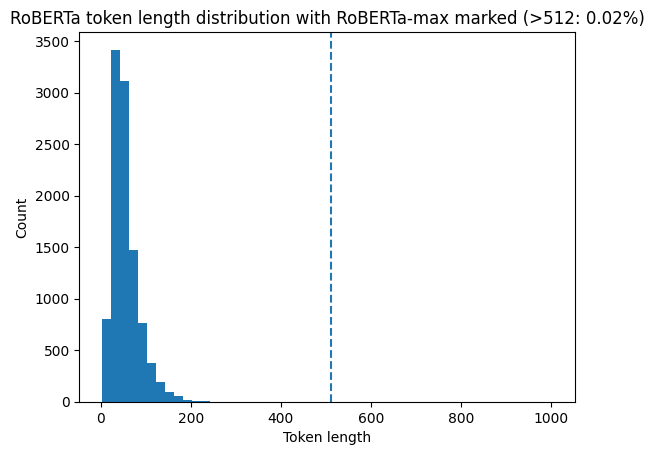

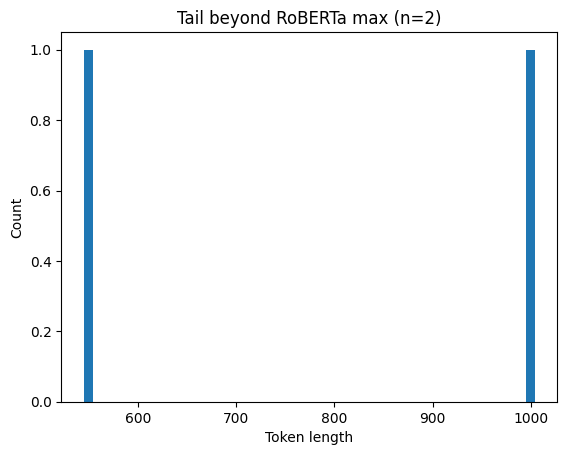

In [62]:
# Compute overflow statistics - how many tokenised inputs exceed model's maximum input size, and what is the distribution?

ROBERTA_MAX_LEN = 512

ov, overflow_lens = overflow_metrics(lengths, ROBERTA_MAX_LEN, "overall")

print(f"RoBERTa model_max_length: {ROBERTA_MAX_LEN}")

print("\n=== Overall Token Length statistics ===")
display(overall_stats.join(ov))

# Plot with max-length marker
plot_hist(
    lengths,
    f"RoBERTa token length distribution with RoBERTa-max marked (>{ROBERTA_MAX_LEN}: {ov['overflow_frac'].iloc[0]:.2%})",
    xline=ROBERTA_MAX_LEN,
)

too_long_mask = lengths > ROBERTA_MAX_LEN

# Tail-only plot (only sequences exceeding model limit)
tail = lengths[too_long_mask]
if tail.size:
    plot_hist(tail, f"Tail beyond RoBERTa max (n={tail.size})")
else:
    print("No samples exceed the RoBERTa max length.")

In [63]:
# Inspecting the overly long texts after
too_long_texts = filtered_data["text"].loc[too_long_mask].to_list()
too_long_encs = tokenizer(too_long_texts, truncation=True, max_length=ROBERTA_MAX_LEN)

truncated_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in too_long_encs["input_ids"]]
truncated_texts

['Most are from desperately poor Horn of Africa countries and like tens of thousands each year , were willing to risk the treacherous journey through war-torn and impoverished Yemen in the hope of finding work in Saudi Arabia and other wealthy Gulf Arab states . But their plan was not to be . Caught and detained by the Yemeni authorities , the 600 or so men now await deportation , prevented from leaving their makeshift jail by armed soldiers . Conditions at the warehouse are growing increasingly desperate . Several days ago , the authorities stopped handing out food and basic supplies . " I came from Djibouti to work . They used to give us small amounts of food . If there is no food , we will die , " said one migrant who declined to give his name . " If there is no solution , they will deport us to our countries or get us out of here " , the man added . Yemen , the poorest country on the Arabian Peninsula , has long been a transit point for migrants and refugees from East Africa , many


=== Class-wise statistics ===

Label = 0


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
No PCL,3,1004,54.979422,31.861272,48.0,1,0.000106,492.0,492.0,492



Label = 1


,min,max,mean,std,median,overflow_count,overflow_frac,excess_mean,excess_median,excess_max
PCL,9,545,61.09894,35.878306,54.0,1,0.001178,33.0,33.0,33


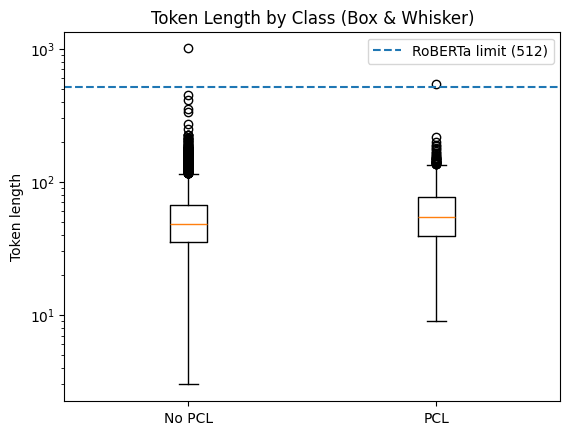

In [64]:
# Class-wise (label=0/1) stats + plots
print("\n=== Class-wise statistics ===")
for lab in [0, 1]:
    lab_mask = (filtered_data["label"] == lab).to_numpy()
    lab_lengths = lengths[lab_mask]

    name = "No PCL" if lab == 0 else "PCL"
    lab_stats = summarise(lab_lengths, name)
    lab_ov, _ = overflow_metrics(lab_lengths, ROBERTA_MAX_LEN, name)
    lab_metrics = lab_stats.join(lab_ov)

    print(f"\nLabel = {lab}")
    display(lab_metrics)

no_pcl = lengths[(filtered_data["label"] == 0).to_numpy()]
pcl    = lengths[(filtered_data["label"] == 1).to_numpy()]

plt.figure()
plt.boxplot(
    [no_pcl, pcl],
    tick_labels=["No PCL", "PCL"],
    showfliers=True,   # show outlier points (set False to hide)
)

plt.axhline(ROBERTA_MAX_LEN, linestyle="--", label=f"RoBERTa limit ({ROBERTA_MAX_LEN})")
plt.ylabel("Token length")
plt.yscale("log")
plt.title("Token Length by Class (Box & Whisker)")
plt.legend()
plt.show()


**Analysis**: The token-length distributions for PCL and non-PCL examples are highly similar, with comparable medians (~50 tokens) and overlapping IQRs, indicating no meaningful class-driven difference in input length. Moreover, the vast majority of samples are short (≈75% lie around ~100 tokens), with only a small right tail of longer documents. Only two instances exceed RoBERTa’s 512-token limit (<0.02% of the data), confirming that long-context cases are extremely rare and not characteristic of either class.

**Impact**: 
As the two classes are comparably distributed in length, no additional preprocessing (e.g., class-specific truncation, padding adjustments, or rebalancing) is required for the remaining inputs. 

Moreover, for the two overlength instances, we can simply truncate these, or drop them. In the case where the entire input is necessary to understand whether or not its PCL (i.e., the connotations, intention, or demeaning nature only becomes prevalent near the end), truncation could destroy the semantic meaning & thus make the input just noisy. However, after manually inspecting the inputs after truncation to 512 tokens, I chose to keep them, as even after truncation, they are rife with a lot of overt forms of PCL and can thus provide rich training signals. I just truncated them further to sentence boundaries to increase grammatical correctness & structure. 

In [65]:
# Truncating the overly long texts to the last sentence <512 tokens.
fixed_truncated_texts = []

for txt in truncated_texts:
    last_period = txt.rfind(".")
    fixed_truncated_texts.append(txt[:last_period+1])

filtered_data.loc[too_long_mask, "text"] = fixed_truncated_texts

### 3. Vocabulary Size
 -- How many unique words exist? This dictates the size of your embedding layer.

In [66]:
from collections import Counter

def clean_roberta_tok(tok):
    return tok.strip("Ġ")

# Compute statistics for DeBERTa token strings.
def compute_vocab_stats(toks: list[str], label: str) -> tuple[Counter, pd.DataFrame]:
    token_counts = Counter(toks)
    vocab_size = len(token_counts)
    total = sum(token_counts.values())

    freq_df = pd.DataFrame({
        "token":       list(token_counts.keys()),
        "token_clean": [clean_roberta_tok(tok) for tok in token_counts.keys()],
        "count":       list(token_counts.values()),
    }).sort_values("count", ascending=False).reset_index(drop=True)

    freq_df["prob"]     = freq_df["count"] / total
    freq_df["cum_prob"] = freq_df["prob"].cumsum()

    top_1k_coverage = freq_df.loc[999, "cum_prob"] if len(freq_df) > 1000 else 1.0
    hapax = int((freq_df["count"] == 1).sum())

    print(f"=== {label} ===")
    print(f"Dataset vocabulary size:    {vocab_size}")
    print(f"Total tokens observed:      {total}")
    print(f"Tokenizer vocab size (ref): {tokenizer.vocab_size}")
    print(f"Top 1k tokens cover:        {top_1k_coverage:.2%} of usage")
    print(f"Hapax tokens (appear once): {hapax} ({hapax / vocab_size:.2%})\n")

    return token_counts, freq_df


def plot_top20(freq_df: pd.DataFrame, title: str, xlabel: str = "Token") -> pd.DataFrame:
    """Display a top-20 frequency table and bar chart for freq_df."""
    top20 = freq_df[["token_clean", "count", "prob", "cum_prob"]].head(20).reset_index(drop=True)

    plt.figure(figsize=(10, 5))
    plt.bar(top20["token_clean"], top20["count"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return top20

=== All tokens ===
Dataset vocabulary size:    28218
Total tokens observed:      551662
Tokenizer vocab size (ref): 50265
Top 1k tokens cover:        69.42% of usage
Hapax tokens (appear once): 8531 (30.23%)



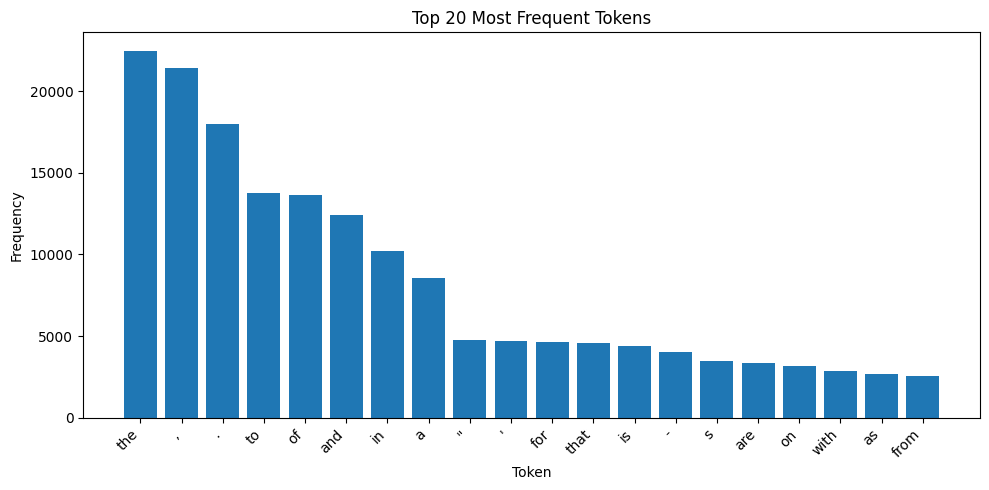

,token_clean,count,prob,cum_prob
0,the,22467,0.040726,0.040726
1,",",21418,0.038824,0.079551
2,.,17982,0.032596,0.112147
3,to,13778,0.024975,0.137122
4,of,13663,0.024767,0.161889
5,and,12405,0.022487,0.184376
6,in,10192,0.018475,0.202851
7,a,8566,0.015528,0.218378
8,"""",4778,0.008661,0.227039
9,',4732,0.008578,0.235617


In [67]:
texts = filtered_data["text"].astype(str).tolist()

def list_tokens_from_texts(texts):
    return [
        tokenizer.convert_ids_to_tokens(tid)
        for seq in tokenise_inputs(texts, add_special_tokens=False)["input_ids"]
        for tid in seq
    ]

all_toks = list_tokens_from_texts(texts)

# --- All tokens ---
token_counts, freq_df = compute_vocab_stats(all_toks, "All tokens")
plot_top20(freq_df, "Top 20 Most Frequent Tokens")

**Analysis**: The dataset uses roughly 55.96% of RoBERTa’s vocabulary, with token usage heavily concentrated: the top 1k tokens account for 69.42% of all occurrences, consistent with a Zipfian distribution. A sizeable long tail (~30.23% hapax tokens) reflects many rare, context-specific terms but relatively low overall frequency.

**Impact**: This balance of a strong core vocabulary and sparse tail is well suited to RoBERTa’s subword modelling, so no vocabulary pruning or additional normalisation is required. The tokenizer can naturally handle rare forms without further preprocessing adjustments.

## Lexical Analysis

### 1. Stop & Filler Word Density 
Following on from the basic vocabulary analysis, we see that there is a domination of stop words, as all of the top 20 tokens are either stop words or filler words. Therefore, we analyse this further.

The `stopwords.txt` list has been manually curated, removing only the most blatant filler/stop words such as articles & prepositions, and prepositions. This is as PCL is a subtle task, and most library stopwords lists are far too aggressive.

In [68]:
with open('stopwords.txt', 'r') as f:
    STOP_WORDS = set(line.strip() for line in f if line.strip())

def is_stop_or_punct(tok, stopword_list = STOP_WORDS):
    clean_tok = clean_roberta_tok(tok).lower()
    
    # remove punctuation / symbols (anything without letters or digits), and remove stop words
    return not any(ch.isalnum() for ch in clean_tok) or (clean_tok in stopword_list) or (len(clean_tok) == 1)


stop_token_count = sum(c for t, c in token_counts.items() if is_stop_or_punct(t))
total_tokens = sum(token_counts.values())
stop_frac = stop_token_count / total_tokens

print(f"Stop-word mass: {stop_frac:.2%} of all tokens")


Stop-word mass: 41.49% of all tokens


=== After stop-word + punctuation removal ===
Dataset vocabulary size:    27865
Total tokens observed:      322772
Tokenizer vocab size (ref): 50265
Top 1k tokens cover:        51.85% of usage
Hapax tokens (appear once): 8509 (30.54%)



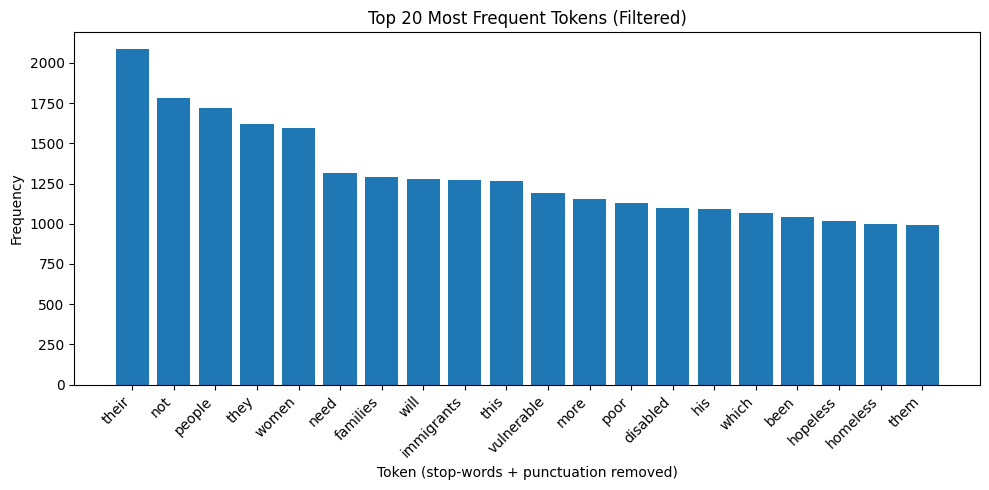

,token_clean,count,prob,cum_prob
0,their,2085,0.006460,0.006460
1,not,1780,0.005515,0.011974
2,people,1722,0.005335,0.017309
3,they,1619,0.005016,0.022325
4,women,1593,0.004935,0.027261
5,need,1317,0.004080,0.031341
6,families,1292,0.004003,0.035344
7,will,1280,0.003966,0.039309
8,immigrants,1273,0.003944,0.043253
9,this,1264,0.003916,0.047170


In [69]:
# --- Stop-words + punctuation removed ---
filtered_toks = [
    tok for tok in all_toks
    if not is_stop_or_punct(tok)
]

token_counts_f, freq_df_f = compute_vocab_stats(filtered_toks, "After stop-word + punctuation removal")
plot_top20(freq_df_f, "Top 20 Most Frequent Tokens (Filtered)", xlabel="Token (stop-words + punctuation removed)")

**Analysis**: Stop-words and punctuation account for 41.49% of all token occurrences, dominating the top 20 most frequent tokens entirely. Once filtered using a minimal stop-word list, the top tokens shift dramatically toward semantically rich terms such as "immigrants", "women", "vulnerable", "poor", "families", revealing that the dataset's content is substantively focused on language directed at marginalised and vulnerable communities.

**Impact**: Since we adopt a pretrained transformer (RoBERTa), stop-word removal is not a preprocessing requirement, as transformers are designed to operate on raw text and capture contextual meaning directly, meaning filler words rarely distort representations. However, this analysis validates that the remaining vocabulary is highly task-relevant, confirming that the dataset carries a strong signal for PCL detection.

### 2. Word Clouds & Frequency 
In this section, we will compare the most task-relevant words between both classes. We will analyse if there are clear lexicon differences between text between these classes, which can clue us in on how easy this task may be (as more profound lexicon-level differences indicate a simpler distinguishing feature).

To achieve this "task-relevant words", we use a more aggressive stop-words list, namely from SpaCy.

 - Do more aggressive stop word removal (e.g., SpaCy), then compute word clouds per class. 
 - Look for categorical & visual differences in the common words. 
 - This gives you a basic idea of what differences exist.

In [70]:
import os 

SPACY_WORDS_LIST_PATH = "spacy_stopwords.txt"

if not os.path.exists(SPACY_WORDS_LIST_PATH):
    !python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm")
SPACY_STOP_WORDS = nlp.Defaults.stop_words
print(len(SPACY_STOP_WORDS))

with open(SPACY_WORDS_LIST_PATH, "w") as f:
    f.write("\n".join(sorted(nlp.Defaults.stop_words)))

326


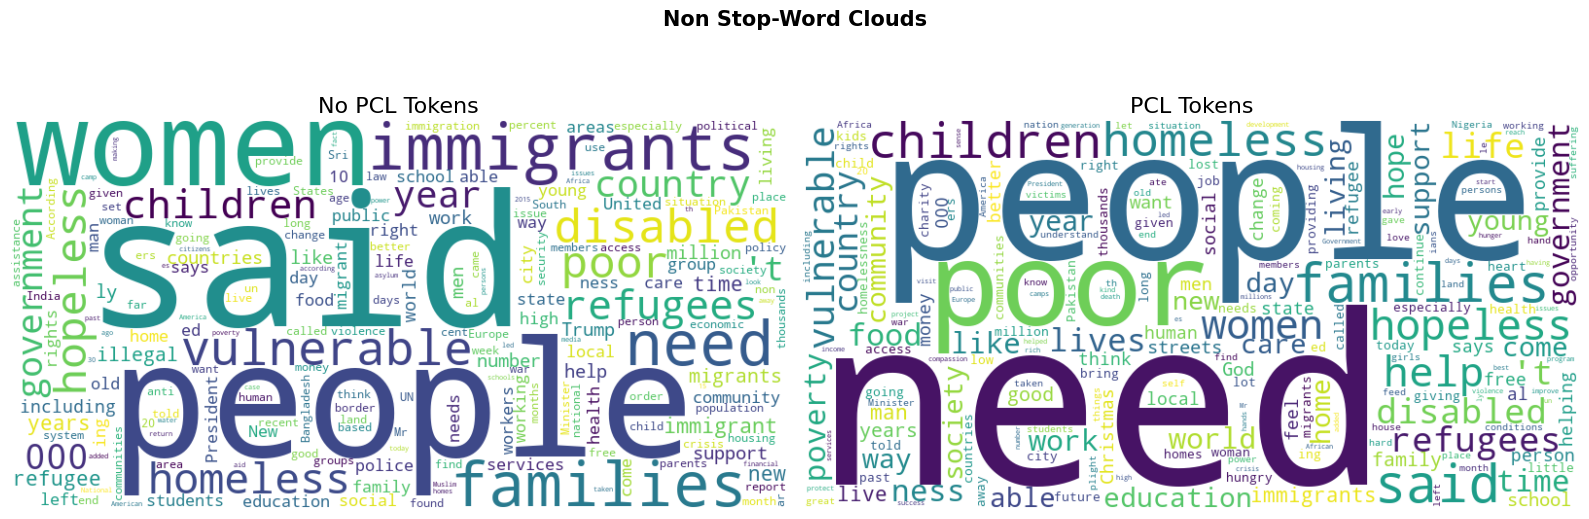

In [71]:
from wordcloud import WordCloud

def relevant_token_distr_per_class(label: int): 
    texts = filtered_data[filtered_data.label == label]["text"].to_list()
    all_toks = list_tokens_from_texts(texts)
    relevant_toks = [clean_roberta_tok(tok) for tok in all_toks if not is_stop_or_punct(tok, SPACY_STOP_WORDS)]
    return Counter(relevant_toks)

no_pcl_token_distr, pcl_token_distr = relevant_token_distr_per_class(0), relevant_token_distr_per_class(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, counter) in zip(axes, [("No PCL Tokens", no_pcl_token_distr), ("PCL Tokens", pcl_token_distr)]):
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(counter)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(label, fontsize=16)

plt.suptitle("Non Stop-Word Clouds", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


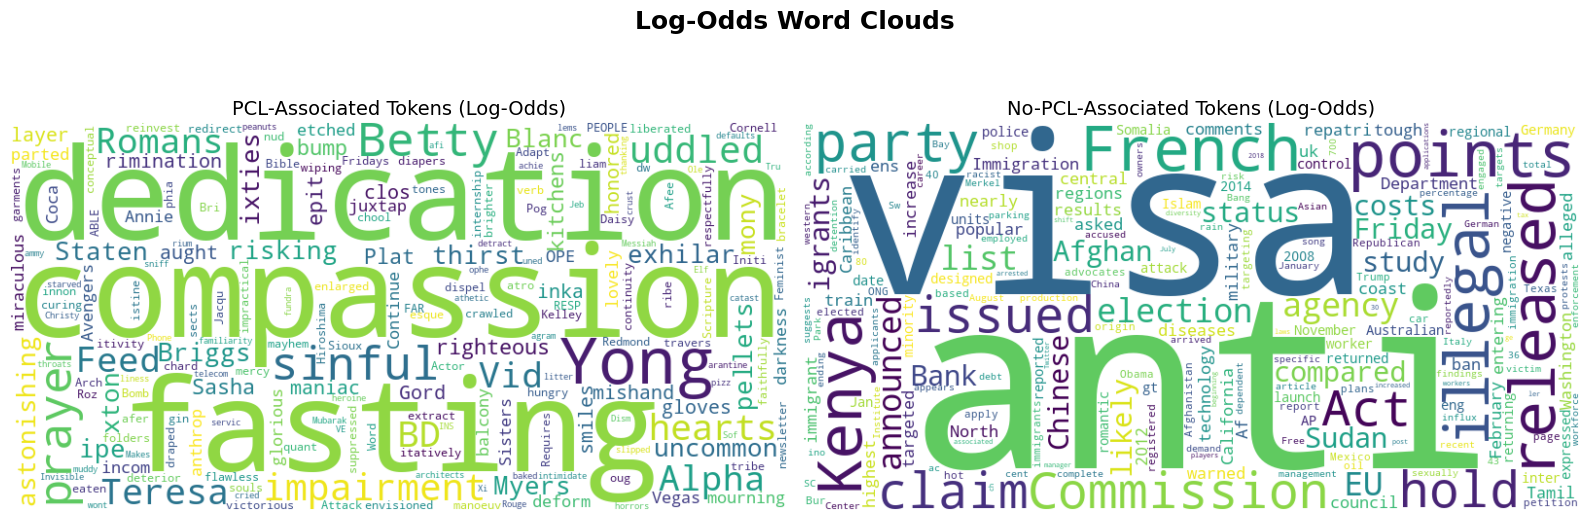

In [72]:
total_pcl = sum(pcl_token_distr.values())
total_no_pcl = sum(no_pcl_token_distr.values())
all_words = set(pcl_token_distr) | set(no_pcl_token_distr)


# Normalize counts to frequency (prob of token given class)
pcl_token_normal = {w: c / total_pcl for w, c in pcl_token_distr.items()}
no_pcl_token_normal = {w: c / total_no_pcl for w, c in no_pcl_token_distr.items()}

import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Log-odds word clouds ---
log_odds = {}
for w in all_words:
    p_pcl = (pcl_token_distr[w] + 1) / (total_pcl + len(all_words))
    p_no_pcl = (no_pcl_token_distr[w] + 1) / (total_no_pcl + len(all_words))
    log_odds[w] = np.log(p_pcl / p_no_pcl)

pcl_log_odds = {w: v for w, v in log_odds.items() if v > 0}
no_pcl_log_odds = {w: abs(v) for w, v in log_odds.items() if v < 0}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, freqs, title in zip(
    axes,
    [pcl_log_odds, no_pcl_log_odds],
    ["PCL-Associated Tokens (Log-Odds)", "No-PCL-Associated Tokens (Log-Odds)"],
):
    wc = WordCloud(width=800, height=400, background_color="white")
    wc.generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

plt.suptitle("Log-Odds Word Clouds", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis**: The overall per-class token frequency clouds show substantial overlap between classes. Particularly, both feature "people", "women", "children", and "families" prominently, reflecting the shared domain of vulnerable communities. However, the log-odds clouds reveal more discriminative signal: PCL-associated tokens skew toward emotionally charged, sacrificial, and patronising language ("fasting", "dedication", "compassion", "impairment"), while No-PCL tokens are more bureaucratic and factual ("visa", "anti", "points", "agency"). This suggests PCL is distinguished not by its subject matter (i.e., the vulnerable groups it refers to), but by its tone toward those subjects.

**Impact**: The moralistic and emotionally loaded PCL-associated tokens suggest that sentiment and tone features could complement token-level representations. This motivates our use of RoBERTa, which can capture these subtle contextual and tonal cues beyond what raw token frequencies reveal, without requiring manual feature engineering around affect or condescension markers.

### 3. Bi/Trigram Analysis
What are the most common pairs (bigrams) or triplets (trigrams) of words? This reveals common phrases or domain-specific jargon.

In [73]:
from nltk.util import ngrams
from collections import Counter

def get_ngrams(texts, n):
    all_ngrams = []
    for text in texts:
        if not isinstance(text, str):
            continue
        tokens = text.lower().split()
        tokens = [t for t in tokens if t not in SPACY_STOP_WORDS and len(t) > 1]
        all_ngrams.extend(ngrams(tokens, n))
    return Counter(all_ngrams)

pcl_texts = filtered_data[filtered_data.label == 1]["text"].tolist()
no_pcl_texts = filtered_data[filtered_data.label == 0]["text"].tolist()

pcl_bigrams = get_ngrams(pcl_texts, 2)
no_pcl_bigrams = get_ngrams(no_pcl_texts, 2)
pcl_trigrams = get_ngrams(pcl_texts, 3)
no_pcl_trigrams = get_ngrams(no_pcl_texts, 3)

# normalize for class imbalance
total_pcl = sum(pcl_bigrams.values())
total_no_pcl = sum(no_pcl_bigrams.values())

def frequency_table(pcl_counter, no_pcl_counter, title, N=20):
    total_pcl = sum(pcl_counter.values())
    total_no_pcl = sum(no_pcl_counter.values())

    pcl_top = {" ".join(k): v / total_pcl for k, v in pcl_counter.most_common(N)}
    no_pcl_top = {" ".join(k): v / total_no_pcl for k, v in no_pcl_counter.most_common(N)}

    pcl_only = {ng: pcl_top[ng] for ng in pcl_top if ng not in no_pcl_top}
    no_pcl_only = {ng: no_pcl_top[ng] for ng in no_pcl_top if ng not in pcl_top}
    common = {ng for ng in pcl_top if ng in no_pcl_top}

    # Common - sorted by absolute gap
    common_df = pd.DataFrame({
        "Ngram": list(common),
        "PCL Freq": [pcl_top[ng] for ng in common],
        "No-PCL Freq": [no_pcl_top[ng] for ng in common],
    })
    common_df["Gap (PCL - No-PCL)"] = (common_df["PCL Freq"] - common_df["No-PCL Freq"]).round(6)
    common_df = common_df.sort_values("Gap (PCL - No-PCL)", ascending=False).reset_index(drop=True)
    common_df.index += 1
    common_df.index.name = "Rank"

    # Unique to PCL
    pcl_only_df = pd.DataFrame({
        "Ngram": list(pcl_only.keys()),
        "PCL Freq": list(pcl_only.values()),
    }).sort_values("PCL Freq", ascending=False).reset_index(drop=True)
    pcl_only_df.index += 1
    pcl_only_df.index.name = "Rank"

    # Unique to No-PCL
    no_pcl_only_df = pd.DataFrame({
        "Ngram": list(no_pcl_only.keys()),
        "No-PCL Freq": list(no_pcl_only.values()),
    }).sort_values("No-PCL Freq", ascending=False).reset_index(drop=True)
    no_pcl_only_df.index += 1
    no_pcl_only_df.index.name = "Rank"

    print(f"\n{'='*60}\n {title}\n{'='*60}")
    print(f"\n── Shared Ngrams (sorted by PCL - No-PCL gap) ──")
    display(common_df)
    print(f"\n── Unique to PCL ──")
    display(pcl_only_df)
    print(f"\n── Unique to No-PCL ──")
    display(no_pcl_only_df)

In [74]:
frequency_table(pcl_bigrams, no_pcl_bigrams, "Bigram Frequency: PCL vs No-PCL")


 Bigram Frequency: PCL vs No-PCL

── Shared Ngrams (sorted by PCL - No-PCL gap) ──


,Ngram,PCL Freq,No-PCL Freq,Gap (PCL - No-PCL)
Rank,,,,
1,poor families,0.006309,0.003748,0.002560
2,people need,0.001303,0.000428,0.000875
3,children poor,0.000938,0.000320,0.000619
4,homeless people,0.001095,0.000541,0.000554
5,women children,0.000521,0.000369,0.000152
6,disabled people,0.000574,0.000517,0.000057
7,men women,0.000521,0.000492,0.000029
8,sri lanka,0.000365,0.000492,-0.000127
9,united states,0.000313,0.000758,-0.000445



── Unique to PCL ──


,Ngram,PCL Freq
Rank,,
1,help need,0.000938
2,vulnerable people,0.000626
3,hundreds thousands,0.000574
4,hope hopeless,0.000521
5,need said,0.000417
6,migrants refugees,0.000417
7,help people,0.000417
8,people disabilities,0.000365
9,pope francis,0.000365



── Unique to No-PCL ──


,Ngram,No-PCL Freq
Rank,,
1,illegal immigrants,0.001495
2,new york,0.000487
3,hong kong,0.000477
4,donald trump,0.000457
5,human rights,0.000418
6,new zealand,0.000344
7,migrant workers,0.000339
8,million people,0.000335
9,united nations,0.000325


In [75]:
frequency_table(pcl_trigrams, no_pcl_trigrams, "Trigram Frequency: PCL vs No-PCL")


 Trigram Frequency: PCL vs No-PCL

── Shared Ngrams (sorted by PCL - No-PCL gap) ──


,Ngram,PCL Freq,No-PCL Freq,Gap (PCL - No-PCL)
Rank,,,,
1,children poor families,0.000982,0.000325,0.000657
2,come poor families,0.000327,0.000124,0.000203
3,help poor families,0.000218,0.000072,0.000146
4,students poor families,0.000164,0.000175,-0.000012



── Unique to PCL ──


,Ngram,PCL Freq
Rank,,
1,think poor families,0.000218
2,brought united states,0.000218
3,hundreds thousands refugees,0.000164
4,food poor families,0.000164
5,poor families given,0.000164
6,help people need,0.000164
7,united states illegally,0.000164
8,states illegally children,0.000164
9,poor families access,0.000164



── Unique to No-PCL ──


,Ngram,No-PCL Freq
Rank,,
1,president donald trump,0.000273
2,un refugee agency,0.000150
3,need humanitarian assistance,0.000098
4,<h> email friend,0.000088
5,world war ii,0.000088
6,dar es salaam,0.000083
7,president barack obama,0.000083
8,working poor families,0.000077
9,high commissioner refugees,0.000072


**Analysis**: At the bigram level, PCL text is dominated by emotionally loaded pairings centred on suffering and need, "poor families", "people need", "children poor", "homeless people", all appearing at significantly higher relative frequencies than in No-PCL text. Whereas, the No-PCL unique bigrams skew toward factual, geopolitical, and institutional language, such as "illegal immigrants", "human rights", "united nations", "prime minister", suggesting more neutral, journalistic writing. The trigram analysis sharpens this further, as PCL trigrams cluster tightly around "poor families" as a core phrase ("children poor families", "come poor families", "help poor families"), indicating a repetitive framing of poverty in an attempt to patronise. 

**Impact**: The stark stylistic contrast between classes — PCL's emotionally charged, need-focused phrasing vs No-PCL's factual institutional language — reinforces that the presence of PCL in the text is evident in the tonality of phrases. Both classes discuss the same communities, but PCL frames them through a lens of helplessness and charity. This suggests that phrase-level context, not just individual tokens, carries meaningful signal, which further motivates the use of RoBERTa, as its attention mechanism can help capture these multi-token patterns and the subtle framing differences they encode, without needing explicit feature engineering around pity-inducing or charity-framing phrases.

In [76]:
# Storing filtered data for use in actual task
filtered_data = filtered_data.drop("token_length", axis=1)
filtered_data.to_csv("data/filtered_pcl_task_data.csv")